<a href="https://colab.research.google.com/github/Haridharshan15/Artificial-Intelligence/blob/main/DL_and_IPGM_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#set reproducability

In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)


In [2]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"haridharshanb","key":"8aca222289f0ade06a80fdbd6e4bed69"}'}

In [3]:
!pip install kaggle

In [4]:
import json
kaggle_credentails = json.load(open("kaggle (1).json"))

In [5]:
import os
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [6]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:52<00:00, 41.4MB/s]



In [7]:
!ls

 drive	'kaggle (1).json'   plantvillage-dataset.zip   sample_data


In [8]:
from zipfile import ZipFile
# Unzip the downloaded dataset
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [9]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'grayscale', 'segmented']
38
['Tomato___Bacterial_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Late_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Cherry_(including_sour)___healthy']
38
['Tomato___Bacterial_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Late_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Cherry_(including_sour)___healthy']
38
['Tomato___Bacterial_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Late_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Cherry_(including_sour)___healthy']


In [10]:
import os
data_dir = '/content/plantvillage dataset/color'
label = []
image_path = []
folds = os.listdir(data_dir)
for fold in folds :
    folder_path = os.path.join(data_dir , fold)
    imgs = os.listdir(folder_path)
    for img in imgs :
        img_path = os.path.join(folder_path , img)
        label.append(fold)
        image_path.append(img_path)
print("Total images:", len(image_path))
print("Total labels:", len(label))

Total images: 54305
Total labels: 54305


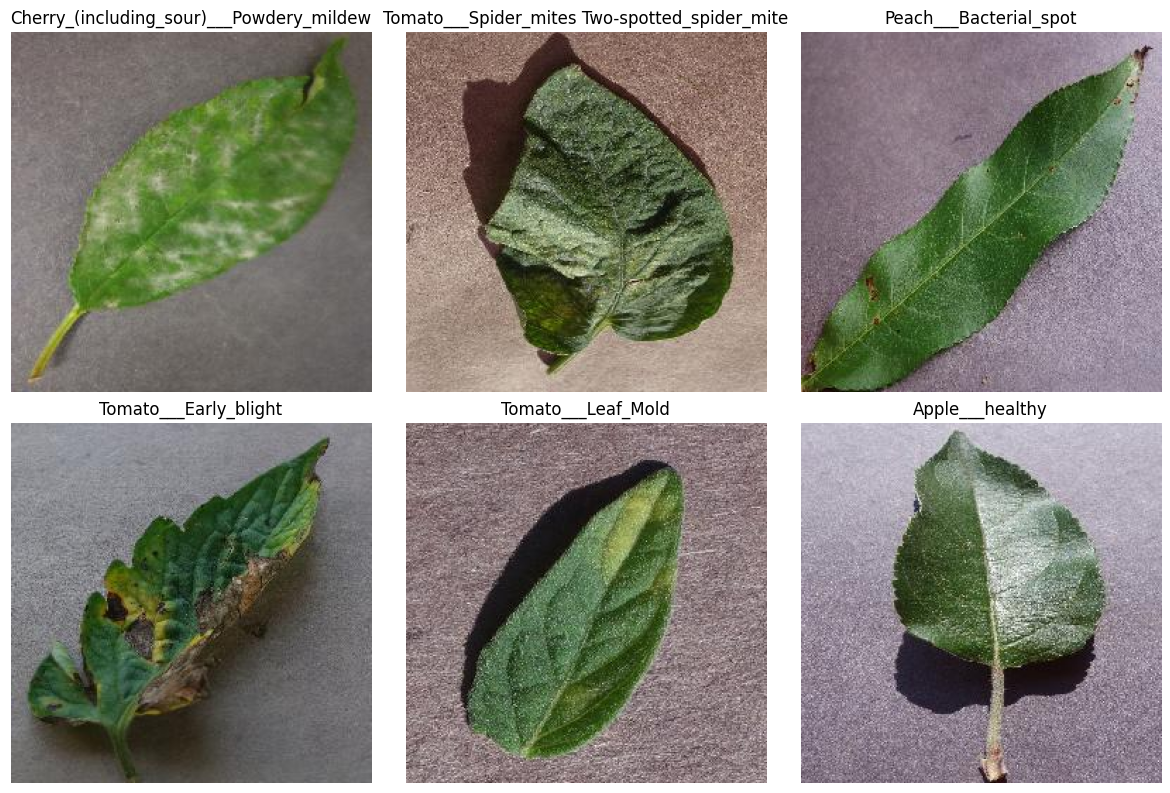

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({'imagepaths': image_path, 'label': label})

plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    rand_idx = np.random.randint(0, len(data))
    img_path = data.iloc[rand_idx]['imagepaths']
    lbl = data.iloc[rand_idx]['label']
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(lbl)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
data.label.value_counts()

,count
label,
Orange___Haunglongbing_(Citrus_greening),5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
Soybean___healthy,5090
Peach___Bacterial_spot,2297
Tomato___Bacterial_spot,2127
Tomato___Late_blight,1909
Squash___Powdery_mildew,1835
Tomato___Septoria_leaf_spot,1771
Tomato___Spider_mites Two-spotted_spider_mite,1676


#Data preprocessing

In [13]:




import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

(256, 256, 3)


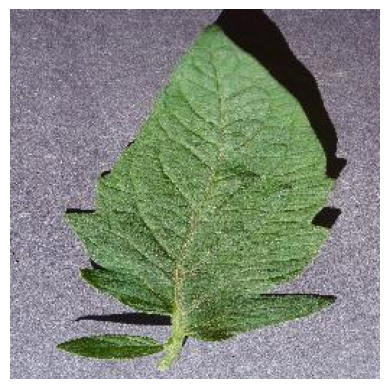

In [14]:
image_path = '/content/plantvillage dataset/color/Tomato___healthy/003944fc-3b99-4a0f-9ed4-0e07352fd8b3___RS_HL 9844.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [15]:
# Read the image
img = mpimg.imread(image_path)

print(img)

[[[113 106 122]
  [110 103 119]
  [135 128 144]
  ...
  [ 85  76  93]
  [103  94 111]
  [109 100 117]]

 [[106  99 115]
  [110 103 119]
  [131 124 140]
  ...
  [ 92  83 100]
  [112 103 120]
  [ 81  72  89]]

 [[111 104 120]
  [116 109 125]
  [122 115 131]
  ...
  [ 67  58  75]
  [100  91 108]
  [101  92 109]]

 ...

 [[163 162 178]
  [184 183 199]
  [165 164 180]
  ...
  [174 172 186]
  [164 162 176]
  [171 169 183]]

 [[149 148 164]
  [192 191 207]
  [135 134 150]
  ...
  [187 185 199]
  [194 192 206]
  [198 196 210]]

 [[134 133 149]
  [137 136 152]
  [172 171 187]
  ...
  [205 203 217]
  [198 196 210]
  [158 156 170]]]


In [16]:
# Image Parameters
img_size = 224
batch_size = 32

#Train and Split

Data Preprocessing WITH Data Augmentation

In [17]:
# Train generator with heavy data augmentation to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [18]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of data for validation
)

In [20]:
# Flow training images in batches
base_dir = '/content/plantvillage dataset/color'
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical',
    shuffle=True
)

Found 43456 images belonging to 38 classes.


In [21]:
# Flow validation images in batches
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

Found 10849 images belonging to 38 classes.


Building CNN Architecture

In [22]:
model = models.Sequential([
    # Block 1: Input and low-level feature extraction
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size, img_size, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2: Mid-level feature extraction
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: High-level abstract feature extraction
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Regularization to prevent overfitting
    layers.Dense(train_generator.num_classes, activation='softmax') # Dynamic output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:

from tensorflow.keras import layers, models, optimizers

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display the final architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,687,238 (197.17 MB)

 Trainable params: 51,687,238 (197.17 MB)

 Non-trainable params: 0 (0.00 B)

Callbacks Setup

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
# Save the best model automatically
checkpoint = ModelCheckpoint(
    filepath='plant_disease_best_model.keras', # .keras is the modern standard extension for Keras 3
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
# Stop early if validation loss stalls
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
# Fine-tune the learning rate if the model gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001,
    verbose=1
)
my_callbacks = [checkpoint, early_stop, reduce_lr]

Training Execution

In [ ]:
history = model.fit(
    train_generator,
    epochs=50, # High epoch count safely managed by EarlyStopping
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=my_callbacks
)

Epoch 1/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.2619 - loss: 2.8133
Epoch 1: val_accuracy improved from None to 0.53033, saving model to plant_disease_best_model.keras

Epoch 1: finished saving model to plant_disease_best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 706s 520ms/step - accuracy: 0.3556 - loss: 2.3480 - val_accuracy: 0.5303 - val_loss: 1.6148 - learning_rate: 0.0010
Epoch 2/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.5335 - loss: 1.6030
Epoch 2: val_accuracy improved from 0.53033 to 0.72364, saving model to plant_disease_best_model.keras

Epoch 2: finished saving model to plant_disease_best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 711s 523ms/step - accuracy: 0.5729 - loss: 1.4414 - val_accuracy: 0.7236 - val_loss: 0.8914 - learning_rate: 0.0010
Epoch 3/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.6589 - loss: 1.1046
Epoch 3: val_accuracy did not improve from 0.72364
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 666s 490ms/step - a

In [ ]:
# Evaluate the model on the entire validation set
from tensorflow.keras.models import load_model

print("Loading the best saved model...")
best_model = load_model('plant_disease_best_model.keras')

# NOW you can run your evaluation
val_loss, val_accuracy = best_model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)

print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")